In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# restauración fuera de foco

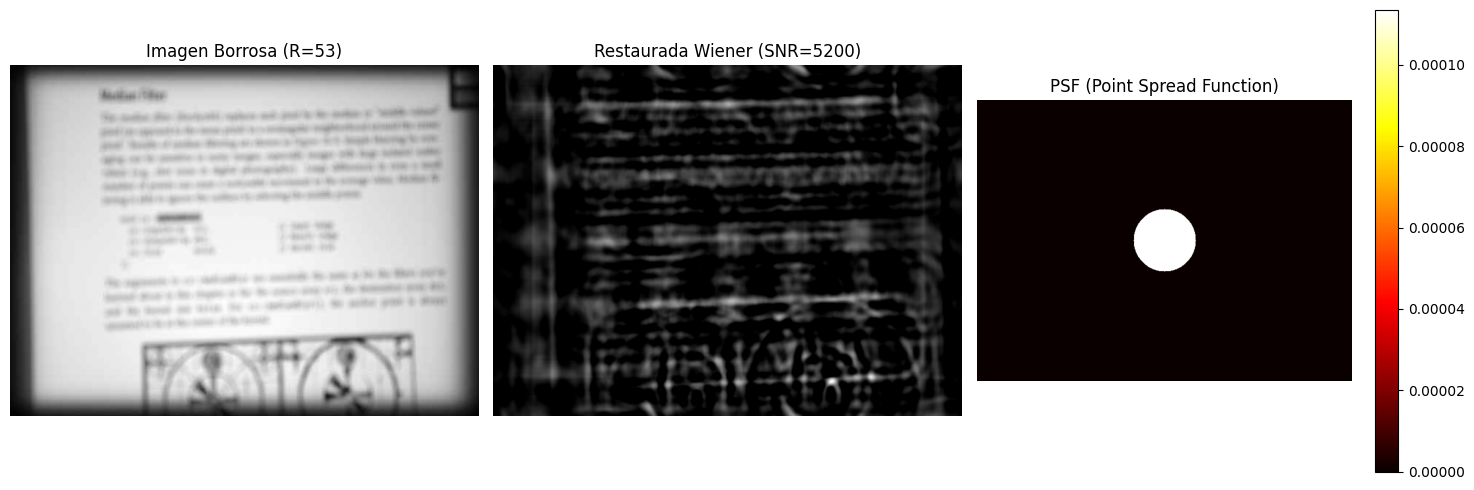

In [18]:

def calc_psf(shape, R):
    """Calcula PSF para desenfoque circular (out-of-focus)"""
    h = np.zeros(shape, dtype=np.float32)
    center = (shape[1]//2, shape[0]//2)
    cv2.circle(h, center, R, 1, -1)
    h = h / np.sum(h)
    return h

def fftshift(img):
    """fftshift para imágenes"""
    return np.fft.fftshift(img)

def ifftshift(img):
    """ifftshift para imágenes"""
    return np.fft.ifftshift(img)

def dft(img):
    """Transformada de Fourier 2D (como en C++)"""
    return np.fft.fft2(img)

def idft(freq):
    """Transformada inversa de Fourier 2D"""
    return np.fft.ifft2(freq)

def filter2dfreq(img, H):
    """Filtrado en frecuencia (como filter2DFreq de C++)"""
    # DFT de la imagen
    G = dft(img)
    
    # Multiplicación en frecuencia (producto elemento por elemento)
    G_filtered = G * H
    
    # IDFT
    result = idft(G_filtered)
    
    return np.real(result)

def calc_wnr_filter(psf, nsr):
    """Calcula filtro Wiener (como calcWnrFilter de C++)"""
    # Aplicar fftshift al PSF
    psf_shifted = fftshift(psf)
    
    # DFT del PSF
    H = dft(psf_shifted)
    
    # |H|^2
    H_abs2 = np.abs(H)**2
    
    # Filtro Wiener: H_conj / (|H|^2 + nsr)
    H_conj = np.conj(H)
    wiener = H_conj / (H_abs2 + nsr)
    
    return wiener

def wiener_filter_out_of_focus(img, R, snr):
    """
    Implementación correcta del filtro Wiener para desenfoque circular
    Basada en el código C++ proporcionado
    """
    # Asegurar dimensiones pares (como en C++)
    rows, cols = img.shape
    rows_even = rows if rows % 2 == 0 else rows - 1
    cols_even = cols if cols % 2 == 0 else cols - 1
    
    if rows != rows_even or cols != cols_even:
        img = img[:rows_even, :cols_even]
    
    # Calcular PSF
    psf = calc_psf(img.shape, R)
    
    # Calcular SNR en el formato correcto
    nsr = 1.0 / snr  # En C++: 1.0/double(snr)
    
    # Calcular filtro Wiener
    Hw = calc_wnr_filter(psf, nsr)
    
    # Aplicar filtro
    img_restored = filter2dfreq(img, Hw)
    
    # Normalizar a [0, 255]
    img_restored = np.clip(img_restored, 0, None)
    img_restored = cv2.normalize(img_restored, None, 0, 255, cv2.NORM_MINMAX)
    img_restored = img_restored.astype(np.uint8)
    
    return img_restored, Hw, psf

def visualizar_wiener(img_blurred, R, snr):
    """Visualización de resultados"""
    img_restored, Hw, psf = wiener_filter_out_of_focus(img_blurred, R, snr)
    
    plt.figure(figsize=(15, 5))
    
    # Original borrosa
    plt.subplot(1, 3, 1)
    plt.title(f'Imagen Borrosa (R={R})')
    plt.imshow(img_blurred, cmap='gray')
    plt.axis('off')
    
    # Restaurada
    plt.subplot(1, 3, 2)
    plt.title(f'Restaurada Wiener (SNR={snr})')
    plt.imshow(img_restored, cmap='gray')
    plt.axis('off')
    
    # PSF
    plt.subplot(1, 3, 3)
    plt.title('PSF (Point Spread Function)')
    plt.imshow(psf, cmap='hot')
    plt.colorbar()
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
    return img_restored

# Ejemplo de uso:
img = cv2.imread('out_of_focus_image.jpg', cv2.IMREAD_GRAYSCALE)
img_restored = visualizar_wiener(img, R=53, snr=5200)

catastrofe

# restauración por desenfoque de movimiento